In [ ]:
using CairoMakie
using MAGEMin_C
using CSV
using DataFrames
using JLD2
using Accessors

# Load local modules explicitly each time Cell 1 is run.
# This avoids notebook state issues and makes modules available to later cells.
include("Modules/LatticeStrainModels.jl")
include("Modules/LSMUtils.jl")
include("Modules/PartitionCoefficients.jl")
include("Modules/LSMPlotting.jl")

import .LatticeStrainModels
import .LSMUtils
import .PartitionCoefficients
import .LSMPlotting

Using libMAGEMin.dylib from MAGEMin_jll


In [ ]:
# Define starting composition

oxides = ["SiO2"; "Al2O3"; "CaO"; "MgO"; "FeO"; "K2O"; "Na2O"; "TiO2"; "O"; "Cr2O3"; "H2O"]
sys_in = "wt"

# For now we fix water content

#h2o = 6.0

"""
    References:

    01SB_872: Blatter, D.L., Sisson, T.W. & Hankins, W.B. Garnet stability in arc basalt, andesite, and dacite—an experimental study. Contrib Mineral Petrol 178, 33 (2023). https://doi.org/10.1007/s00410-023-02008-w

    SLLB0412: Simon J E Large, Chetan L Nathwani, Jamie J Wilkinson, Thomas R Knott, Simon R Tapster, Yannick Buret, Tectonic and Crustal Processes Drive Multi-Million Year Arc Magma Evolution Leading up to Porphyry Copper Deposit Formation in Central Chile, Journal of Petrology, Volume 65, Issue 4, April 2024, egae023, https://doi.org/10.1093/petrology/egae023

"""

Basalt_SB_872 = [50.07802738736208, 17.060650612928963, 10.035676831134685, 8.70093181259377, 9.313108099292986, 0.4917481647255995, 3.0307744030026744, 1.2544596038918356, 0.0, 0.03462308506741466, 0.0]

# Large composition

SLLB0412 = [50.4, 16.9, 9.0, 7.29, 7.675294, 1.18, 3.8, 0.84, 0.0, 2.4e-2, 0.0]

# renormalize to 100 wt.%

SLLB0412 = SLLB0412 ./ sum(SLLB0412) .* 100
Basalt_SB_872 = Basalt_SB_872 ./ sum(Basalt_SB_872) .* 100

# Print both compositions to 3 significant figures
println("SLLB0412: $(round.(SLLB0412, sigdigits=3))")
println("Basalt_SB_872: $(round.(Basalt_SB_872, sigdigits=3))")


# Trace elements

elements = [:La, :Ce, :Pr, :Nd, :Sm, :Eu, :Gd, :Tb, :Dy, :Ho, :Er, :Tm, :Yb, :Lu, :Sr, :Y]

charges = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3]

TE_0s_dict = Dict{String, Vector{Float64}}(
    "SLLB0412" => [13.62,	26.07666667,	3.033333333,	11.49666667,	3.013333333,	0.981333333,	3.023333333,	0.475,	2.773333333,	0.573666667,	1.594666667,	0.231333333,	1.539666667,	0.229,	497.0,	16.0],
     "Basalt_SB_872" => [8.7,	19.8,	2.77,	12.4,	3.31,	1.23,	3.7,	0.64,	4.04,	0.82,	2.23,	0.32,	1.99,	0.31,	367.0,	21.0]
)


In [3]:
# Print TE_0s_dict entries to 3 significant figures
for (key, value) in TE_0s_dict
    println("$key: $(round.(value, sigdigits=3))")
end

Basalt_SB_872: [8.7, 19.8, 2.77, 12.4, 3.31, 1.23, 3.7, 0.64, 4.04, 0.82, 2.23, 0.32, 1.99, 0.31, 367.0, 21.0]
SLLB0412: [13.6, 26.1, 3.03, 11.5, 3.01, 0.981, 3.02, 0.475, 2.77, 0.574, 1.59, 0.231, 1.54, 0.229, 497.0, 16.0]


In [ ]:
# Set up grid search over pressures
# Range from 2.0 to 10.0 kbar, step size 0.5 kbar

pressures = collect(2.0:0.5:10.0)
#pressures = [2.0, 4.0, 6.0, 8.0]

residuals = zeros(length(pressures))

# Targets -> ME and TE compositions

RIE03_barren_ME = [68.98818982897475, 15.994527146614326, 2.9767009892781573, 1.582682568242964, 1.9145014015871018, 3.270178551601356, 4.706122338682722, 0.5659924416233116, 0.0, 0.001104733395316612, 0.0] .* (1.0 - h2o/100)
ORT04_prospect_ME =  [71.79091191395173, 15.224322916270033, 2.149921276689484, 1.0080970579692319, 1.2773153667013417, 3.312318904756048, 4.8758980150756726, 0.36003466356043995, 0.0, 0.0011798850260109277, 0.0] .* (1.0 - h2o/100)
SLLB0802_deposit_ME = [68.24841545840141, 18.261034520133812, 2.6723465151415335, 1.0668670196107672, 1.1230598235426252, 2.20623956482615, 5.955811031807682, 0.46610695031538374, 0.0, 0.00011911622063615361, 0.0] .* (1.0 - h2o/100)

RIE03_barren_TE = [16.0186, 32.226075, 3.717835, 13.0136, 2.8861299999999996, 0.704156, 2.8062025, 0.40397375, 2.3684450000000004, 0.53138475, 1.5935425, 0.24280075, 1.6308525, 0.27541350000000003, 290.15, 16.69]
ORT04_prospect_TE = [18.212433333333333, 33.5385, 3.5580366666666667, 11.506766666666666, 2.1896566666666666, 0.5753813333333334, 2.3001966666666664, 0.24006033333333335, 1.1956666666666667, 0.27049433333333334, 0.699517, 0.11773766666666667, 0.7379326666666667, 0.11236033333333334, 348.96, 8.24]
SLLB0802_deposit_TE = [17.213333333333335, 35.0, 4.140000000000001, 14.686666666666667, 2.74, 0.7666666666666666, 1.7466666666666668, 0.21733333333333335, 1.1420000000000001, 0.20299999999999999, 0.52, 0.09300000000000001, 0.4723333333333333, 0.07133333333333335, 757.71, 5.62]






In [12]:
function ECX_run_buffered(bulk_0::Vector{Float64}, TE_0::Vector{Float64}, P::Vector{Float64}, T::Vector{Float64}, boff::Vector{Float64})

    """
     Input:

        bulk_0: Vector of initial bulk composition 
                Input format, mol% or wt%, as well as oxides need to be defined outside of this function
        
        TE_0: Vector of initial trace element concentrations in ppm
              Elements and their charges need to be defined outside of this function

        P: Vector of pressures for each step in kbar

        T: Vector of temperatures for each step in °C

        boff: Vector of buffer offsets for each step in log units
              Buffer needs to be defined outside of this function

    Output:

        Out_XY: Vector of MAGEMin outputs from single point minimization for each step

        Out_Sat: Vector of outputs from MAGEMin saturation model for each step

        Out_TE: Vector of dictionaries of trace element concentrations for each step
                Out_TE[Int(step)][String("phase")][Symbol(:element)] gives the concentration of that element in that phase for that step

        Out_Ds: Vector of dictionaries ofpartition coefficients for each step
                Out_Ds[Int(step)][String("phase")][Symbol(:element)] gives the concentration of that element in that phase for that step
                
        Out_EuR: Vector of Eu/R ratio for each step
    
    """

    # Globals defined in other cells; copy into local bindings for safe, fast access
    sys_in_local    = sys_in
    oxides_local    = oxides
    sat_C0s_local   = sat_C0s
    sat_KdsDB_local = sat_KdsDB
    elements_local  = elements
    charges_local   = charges
    buffer_local    = buffer


    # Initalize MAGEMin
    data = Initialize_MAGEMin("ig", buffer=buffer_local, verbose=false)

    rm_list = remove_phases(["ne", "sph", "ky", "sill", "and", "ep", "fper", "chl", ],"ig");


    # Initialize melt fraction
    meltF = 1.0
    # Initialize counter
    np = 0
    nsteps = length(T)


    # Initialize output storage
    Out_XY = Vector{out_struct}(undef, nsteps)
    Out_Sat = Vector{out_TE_struct}(undef, nsteps)


    # Out_TE should be a vector of dictionaries, where each dictionary corresponds to a step. Each step-dictionary is to be structured like Dict("phase" => Dict(:element => value))
    Out_TE = Vector{Dict{String,Dict{Symbol,Float64}}}(undef, nsteps)


    # Similar to Out_TE 
    Out_Ds = Vector{Dict{String,Dict{Symbol,Float64}}}(undef, nsteps)

    Out_EuR = zeros(Float64, nsteps)

    param_dicts = [Dict{Symbol,Float64}() for _ in 1:nsteps]

    while meltF > 0.0 && np < nsteps

        np += 1

        # Reset initial bulk composition -> No melt sequestration
        bulk = deepcopy(bulk_0)
        sys_in_local = sys_in

        Out_TE[np] = Dict{String,Dict{Symbol,Float64}}()
        Out_Ds[np] = Dict{String,Dict{Symbol,Float64}}()

        # If input bulk composition is in wt.%, convert to mol.%
        if sys_in_local == "wt"
            bulk, oxides_local = convertBulk4MAGEMin(bulk, oxides_local, "wt", "ig")
            sys_in_local = "mol"
        end

        # Routine from https://computationalthermodynamics.github.io/MAGEMin_C.jl/dev/MAGEMin_C/saturation_models#E.4-Saturation-models-and-bulk-correction
        tol = 1e-6
        res = 1.0
        n0 = 0.0
        ite = 0

        while res > tol && ite < 32
            #println(bulk)
            out = single_point_minimization(P[np], T[np], data, X=bulk, Xoxides=oxides_local, B=boff[np], sys_in=sys_in_local, name_solvus=true, rm_list=rm_list)
            Out_XY[np] = deepcopy(out) # Store output

            Out_Sat[np] = TE_prediction(out, sat_C0s_local, sat_KdsDB_local, "ig";
                ZrSat_model="CB",
                P2O5Sat_model="Klein26")


            # Reset P_kbar 
            #out = @set out.P_kbar = pkbar
            bulk .-= Out_Sat[np].bulk_cor_mol
            res = abs(n0 - vec_norm(Out_Sat[np].bulk_cor_mol))
            n0 = vec_norm(Out_Sat[np].bulk_cor_mol)

            ite += 1
            if ite == 32
                @warn "Saturation model did not converge in 32 iterations, residual is $res"
            end

        end

        out = Out_XY[np] # Get the output of the single point minimization for this step

        out_sat = Out_Sat[np] # Get the output of the saturation model for this step

        # Reset oxides
        if np == 1
            oxides_local = ["SiO2"; "Al2O3"; "CaO"; "MgO"; "FeO"; "K2O"; "Na2O"; "TiO2"; "O"; "Cr2O3"; "H2O"]
        end


        # If any of the entries in bulk are NaN, set them to the original value from bulk_0
        for i in eachindex(bulk)
            if isnan(bulk[i])
                bulk[i] = bulk_0[i]
            else
                # Nothing to do
            end
        end


        meltF = out.frac_M
        #println("Step $np: Melt Fraction = $meltF")
        # Break loop if melt fraction is zero or negative (which can happen due to numerical issues)
        if meltF <= 0.0
            println("Melt fraction is zero or negative, stopping iteration at step $np.")
            break
        end
        meltF_wt = out.frac_M_wt

        outte = Dict{String,Dict{Symbol,Float64}}()
        out_d = Dict{String,Dict{Symbol,Float64}}()

        phases = copy(out.ph)

        # Work on a local copy of phase fractions so the output `out` is unchanged
        phase_fracs_wt = copy(out.ph_frac_wt)

        # Add 'zr' and 'ap' to phases if zrc_wt > 0 and fapt_wt > 0, respectively
        # Append fractions to the local `phase_fracs_wt` to keep alignment
        if out_sat.zrc_wt > 0.0 && !("zr" in phases)
            push!(phases, "zr")
            push!(phase_fracs_wt, out_sat.zrc_wt)
        end
        if out_sat.fapt_wt > 0.0 && !("ap" in phases)
            push!(phases, "ap")
            push!(phase_fracs_wt, out_sat.fapt_wt)
        end

        for phase in phases
            params = LSMUtils.get_params_for_phase(phase, out, out_sat, T[np], P[np])
            # Skip buffer and melt
            if phase in ["liq", buffer]
                out_d[phase] = Dict(el => 0.0 for el in elements)
            else
                Dphase = PartitionCoefficientsV2.get_D(phase, elements, charges, params)
                out_d[phase] = Dphase
            end
        end

        params = LSMUtils.get_params_for_phase("liq", out, out_sat, T[np], P[np])

        Out_EuR[np] = LSMUtils.Eu_ratio_Burnham(params[:logfO2], params[:T], params[:Λ])

        # Need to normalize phase_fracs_wt to 1 while omitting "liq" and "buffer" fractions, it can be done for all fractions as "liq" and "buffer" have zero Kds and thus do not contribute to the sum
        if "liq" in phases
            # I want to normalize phase fractions such that the sum of all fractions excluding "liq" is 1.0, "liq" fraction can also be modified, it won't have any effect as Kd is 0
            phase_fracs_wt_used = phase_fracs_wt ./ (1.0 - phase_fracs_wt[findfirst(==("liq"), phases)])
            #=if mod(np, 10) == 0
                println("Step $np: Normalized phase fractions (excluding 'liq') = $phase_fracs_wt_used")
            end=#
        else
            phase_fracs_wt_used = phase_fracs_wt ./ sum(phase_fracs_wt)
        end

        has_other_phases = any(phase -> !(phase in ["liq", buffer]), phases)

        if has_other_phases
            Kd = Dict(el => sum((phase_fracs_wt_used[i] * get(out_d[phases[i]], el, 0.0) for i in eachindex(phases)); init=0.0) for el in elements)

            # Add Kd to out_d with key "bulk"
            out_d["bulk"] = Kd

            Out_TE[np]["liq"] = Dict(el => TE_0[i] / (Kd[el] + meltF_wt * (1.0 - Kd[el])) for (i, el) in enumerate(elements))
        else
            out_d["bulk"] = Dict(el => NaN for el in elements)

            Out_TE[np]["liq"] = Dict(el => TE_0[i] for (i, el) in enumerate(elements))
        end

        for phase in phases
            # Skip buffer and melt
            if phase in ["liq", buffer]
                continue
            else
                # Compute trace element concentrations in this phase
                Out_TE[np][phase] = Dict(el => Out_TE[np]["liq"][el] * get(out_d[phase], el, 0.0) for el in elements)
            end
        end

        Out_Ds[np] = out_d

    end

    return Out_XY[1:np], Out_Sat[1:np], Out_TE[1:np], Out_Ds[1:np], Out_EuR[1:np], param_dicts[1:np]

end

ECX_run_buffered (generic function with 1 method)

In [13]:
function FCX_run_buffered(bulk_0::Vector{Float64}, TE_0::Vector{Float64}, P::Vector{Float64}, T::Vector{Float64}, boff::Vector{Float64})


    """
     Input:

        bulk_0: Vector of initial bulk composition 
                Input format, mol% or wt%, as well as oxides need to be defined outside of this function
        
        TE_0: Vector of initial trace element concentrations in ppm
              Elements and their charges need to be defined outside of this function

        P: Vector of pressures for each step in kbar

        T: Vector of temperatures for each step in °C

        boff: Vector of buffer offsets for each step in log units
              Buffer needs to be defined outside of this function

    Output:

        Out_XY: Vector of MAGEMin outputs from single point minimization for each step

        Out_Sat: Vector of outputs from MAGEMin saturation model for each step

        Out_TE: Vector of dictionaries of trace element concentrations for each step
                Out_TE[Int(step)][String("phase")][Symbol(:element)] gives the concentration of that element in that phase for that step

        Out_Ds: Vector of dictionaries ofpartition coefficients for each step
                Out_Ds[Int(step)][String("phase")][Symbol(:element)] gives the concentration of that element in that phase for that step
                
        Out_EuR: Vector of Eu/R ratio for each step
    
    """


    # Globals defined in other cells; copy into local bindings for safe, fast access
    sys_in_local    = sys_in
    oxides_local    = oxides
    sat_C0s_local   = sat_C0s
    sat_KdsDB_local = sat_KdsDB
    elements_local  = elements
    charges_local   = charges
    buffer_local    = buffer


    # Initalize MAGEMin
    data = Initialize_MAGEMin("ig", buffer=buffer_local, verbose=false)
    rm_list = remove_phases(["ne", "sph", "ky", "sill", "and", "ep", "fper", "chl", ],"ig");


    # Initialize melt fraction
    meltF = 1.0
    # Initialize counter
    np = 0
    nsteps = length(T)

    # Copy bulk_0 once for initialiazation
    bulk = deepcopy(bulk_0)
    sys_in_local = sys_in


    # Initialize output storage
    Out_XY = Vector{out_struct}(undef, nsteps)
    Out_Sat = Vector{out_TE_struct}(undef, nsteps)


    # Out_TE should be a vector of dictionaries, where each dictionary corresponds to a step. Each step-dictionary is to be structured like Dict("phase" => Dict(:element => value))
    Out_TE = Vector{Dict{String,Dict{Symbol,Float64}}}(undef, nsteps)


    # Similar to Out_TE 
    Out_Ds = Vector{Dict{String,Dict{Symbol,Float64}}}(undef, nsteps)

    Out_EuR = zeros(Float64, nsteps)

    param_dicts = [Dict{Symbol,Float64}() for _ in 1:nsteps]

    while meltF > 0.0 && np < nsteps

        np += 1

        Out_TE[np] = Dict{String,Dict{Symbol,Float64}}()
        Out_Ds[np] = Dict{String,Dict{Symbol,Float64}}()

        # If input bulk composition is in wt.%, convert to mol.%
        if sys_in_local == "wt"
            bulk, oxides_local = convertBulk4MAGEMin(bulk, oxides_local, "wt", "ig")
            sys_in_local = "mol"
        end

        # Routine from https://computationalthermodynamics.github.io/MAGEMin_C.jl/dev/MAGEMin_C/saturation_models#E.4-Saturation-models-and-bulk-correction
        tol = 1e-6
        res = 1.0
        n0 = 0.0
        ite = 0

        while res > tol && ite < 32
            #println(bulk)
            out = single_point_minimization(P[np], T[np], data, X=bulk, Xoxides=oxides_local, B=boff[np], sys_in=sys_in_local, name_solvus=true, rm_list=rm_list)
            Out_XY[np] = deepcopy(out) # Store output

            Out_Sat[np] = TE_prediction(out, sat_C0s_local, sat_KdsDB_local, "ig";
                ZrSat_model="CB",
                P2O5Sat_model="Klein26")


            # Reset P_kbar 
            #out = @set out.P_kbar = pkbar
            bulk .-= Out_Sat[np].bulk_cor_mol
            res = abs(n0 - vec_norm(Out_Sat[np].bulk_cor_mol))
            n0 = vec_norm(Out_Sat[np].bulk_cor_mol)

            ite += 1
            if ite == 32
                @warn "Saturation model did not converge in 32 iterations, residual is $res"
            end

        end

        out = Out_XY[np] # Get the output of the single point minimization for this step

        out_sat = Out_Sat[np] # Get the output of the saturation model for this step

        # Reset oxides
        if np == 1
            oxides_local = ["SiO2"; "Al2O3"; "CaO"; "MgO"; "FeO"; "K2O"; "Na2O"; "TiO2"; "O"; "Cr2O3"; "H2O"]
        end

        # Update bulk for next iteration
        bulk = out.bulk_M


        # If any of the entries in bulk are NaN, set them to the original value from bulk_0
        for i in eachindex(bulk)
            if isnan(bulk[i])
                bulk[i] = bulk_0[i]
            else
                # Nothing to do
            end
        end


        meltF = out.frac_M
        #println("Step $np: Melt Fraction = $meltF")
        # Break loop if melt fraction is zero or negative (which can happen due to numerical issues)
        if meltF <= 0.0
            println("Melt fraction is zero or negative, stopping iteration at step $np.")
            break
        end
        meltF_wt = out.frac_M_wt

        outte = Dict{String,Dict{Symbol,Float64}}()
        out_d = Dict{String,Dict{Symbol,Float64}}()

        phases = copy(out.ph)

        # Work on a local copy of phase fractions so the output `out` is unchanged
        phase_fracs_wt = copy(out.ph_frac_wt)

        # Add 'zr' and 'ap' to phases if zrc_wt > 0 and fapt_wt > 0, respectively
        # Append fractions to the local `phase_fracs_wt` to keep alignment
        if out_sat.zrc_wt > 0.0 && !("zr" in phases)
            push!(phases, "zr")
            push!(phase_fracs_wt, out_sat.zrc_wt)
        end
        if out_sat.fapt_wt > 0.0 && !("ap" in phases)
            push!(phases, "ap")
            push!(phase_fracs_wt, out_sat.fapt_wt)
        end

        for phase in phases
            params = LSMUtils.get_params_for_phase(phase, out, out_sat, T[np], P[np])
            # Skip buffer and melt
            if phase in ["liq", buffer]
                out_d[phase] = Dict(el => 0.0 for el in elements)
            else
                Dphase = PartitionCoefficientsV2.get_D(phase, elements, charges, params)
                out_d[phase] = Dphase
                #Out_TE[np][phase] = Dict(el => TE_now[i] * Dphase[el] for (i, el) in enumerate(elements))
                if np==1
                    Out_TE[np][phase] = Dict(el => TE_0[i] * Dphase[el] for (i, el) in enumerate(elements))
                else
                    Out_TE[np][phase] = Dict(el => Out_TE[np-1]["liq"][el] * Dphase[el] for (i, el) in enumerate(elements))
                end
            end
        end

        params = LSMUtils.get_params_for_phase("liq", out, out_sat, T[np], P[np])

        Out_EuR[np] = LSMUtils.Eu_ratio_Burnham(params[:logfO2], params[:T], params[:Λ])

        # Need to normalize phase_fracs_wt to 1 while omitting "liq" and "buffer" fractions, it can be done for all fractions as "liq" and "buffer" have zero Kds and thus do not contribute to the sum
        if "liq" in phases
            # I want to normalize phase fractions such that the sum of all fractions excluding "liq" is 1.0, "liq" fraction can also be modified, it won't have any effect as Kd is 0
            phase_fracs_wt_used = phase_fracs_wt ./ (1.0 - phase_fracs_wt[findfirst(==("liq"), phases)])
            #=if mod(np, 10) == 0
                println("Step $np: Normalized phase fractions (excluding 'liq') = $phase_fracs_wt_used")
            end=#
        else
            phase_fracs_wt_used = phase_fracs_wt ./ sum(phase_fracs_wt)
        end
        has_other_phases = any(ph -> !(ph in ["liq", buffer]), phases)

        if has_other_phases
            Kd = Dict(el => sum((phase_fracs_wt_used[i] * get(out_d[phases[i]], el, 0.0) for i in eachindex(phases)); init=0.0) for el in elements)

            # Add Kd to out_d with key "bulk"
            out_d["bulk"] = Kd

            if np == 1
                Out_TE[np]["liq"] = Dict(el => TE_0[i] / (Kd[el] + meltF_wt * (1.0 - Kd[el])) for (i, el) in enumerate(elements))
            else
                Out_TE[np]["liq"] = Dict(el => Out_TE[np-1]["liq"][el] / (Kd[el] + meltF_wt * (1.0 - Kd[el])) for (i, el) in enumerate(elements))
            end
        else
            Kd = Dict(el => NaN for el in elements)

            # Add Kd to out_d with key "bulk"
            out_d["bulk"] = Kd

            if np==1
                Out_TE[np]["liq"] = Dict(el => TE_0[i] for (i, el) in enumerate(elements))
            else
                Out_TE[np]["liq"] = Dict(el => Out_TE[np-1]["liq"][el] for (i, el) in enumerate(elements))
            end
        end

        Out_Ds[np] = out_d

    end

    return Out_XY[1:np], Out_Sat[1:np], Out_TE[1:np], Out_Ds[1:np], Out_EuR[1:np], param_dicts[1:np]

end

FCX_run_buffered (generic function with 1 method)

In [14]:

# For zircon and apatite saturation models
sat_elements = ["Zr", "P2O5"]
#sat_phases = ["zrc", "fapt"]
sat_phases = ["cpx", "pig", "Na-cpx", "opx", "pl", "afs", "amp", "gl", "act", "cumm", "tr", "bi", "g", "ilm", "hem", "ep", "ru", "spl", "cm", "usp", "mgt", "zr", "ap"]
# Fixed Kds from Bédard 2006; DOI:10.1016/j.gca.2005.11.008
sat_Kds = [ "0.125" "0.162";
            "0.125" "0.162";
            "0.125" "0.162";
            "0.031" "0.050";
            "0.078" "0.079";
            "0.078" "0.079";
            "0.417" "0.225";
            "0.417" "0.225";
            "0.417" "0.225";
            "0.417" "0.225";
            "0.417" "0.225";
            "0.023" "0.005";
            "0.537" "0.184";
            "2.3" "0.002";
            "2.3" "0.002";
            "0.10" "0.18";
            "3.7" "0.03";
            "0.12" "0.024";
            "0.12" "0.024";
            "0.12" "0.024";
            "0.12" "0.024";
            "0.0" "20.0";
            "16.0" "0.0"]

sat_C0s_dict = Dict{String, Vector{Float64}}("Basalt_SB_872" => [96.0, 0.22e4], "SLLB0412" => [85.0, 0.18e4])

sat_KdsDB = create_custom_KDs_database(sat_elements, sat_phases, sat_Kds)

sat_models = ["CB", "Klein26"]

2-element Vector{String}:
 "CB"
 "Klein26"

In [6]:
T = collect(1300.0:-5.0:600.0)
buffer = "qfm"
dfO2 = 1.0
boff = zeros(length(T)) .+ dfO2
nsteps = length(T)

141

In [ ]:
# Grid search

# Iterate over pressures and run FCX for each pressure, compute residuals and store them

#RIE03_barren, SLLB0802_deposit

#moltarget,_ = convertBulk4MAGEMin(RIE03_barren_ME, oxides, "wt", "ig")
SiO2_target = SLLB0802_deposit_ME[1]
TEtarget = SLLB0802_deposit_TE
La_Yb_target = TEtarget[1] / TEtarget[13]
Sr_Y_target = TEtarget[15] / TEtarget[16]
Eu_an_target = TEtarget[6] / sqrt(TEtarget[5] * TEtarget[7])



# Buffered version

for (i, pr) in enumerate(pressures)
    P = fill(pr, length(T))
    println("Running buffered ECX for P = $pr kbar")
    Out_XY, Out_Sat, Out_TE, Out_Ds, Out_EuR, param_dicts = ECX_run_buffered(SLLB0412, TE_0, P, T, boff)

    # Use the first step where SiO2 in the bulk exceeds the target; otherwise fall back to the penultimate step
    # Renormalize MAGEMin output to anhydrous
    target_step = findfirst(out -> out.bulk_M_wt[1]*100.0 > SiO2_target, Out_XY)
    if target_step === nothing
        @warn "SiO2 target was not reached for P = $pr kbar; using Out_TE[end-1][\"liq\"] instead."
        target_step = max(length(Out_TE) - 1, 1)
    end

    # Extract the liquid trace element composition at the comparable step
    TE_liq = Out_TE[target_step]["liq"]

    # Calculate La/Yb
    La_Yb_liq = TE_liq[:La] / TE_liq[:Yb]
    # Calculate Sr/Y
    Sr_Y_liq = TE_liq[:Sr] / TE_liq[:Y]
    # Calculate Eu anomaly
    #Eu_an_liq = TE_liq[:Eu] / sqrt(TE_liq[:Sm] * TE_liq[:Gd])

    #residuals[i] = sqrt((La_Yb_liq - La_Yb_target)^2 / La_Yb_target^2 + (Sr_Y_liq - Sr_Y_target)^2 / Sr_Y_target^2 + (Eu_an_liq - Eu_an_target)^2 / Eu_an_target^2)
    residuals[i] = sqrt((La_Yb_liq - La_Yb_target)^2 / La_Yb_target^2 + (Sr_Y_liq - Sr_Y_target)^2 / Sr_Y_target^2)
end

# Get the minimum residual and corresponding pressure
min_residual, min_index = findmin(residuals)
best_pressure = pressures[min_index]
println("Best pressure: $best_pressure kbar with residual: $min_residual")


In [8]:
println(residuals)

[0.5146908196287837, 0.5409872522264073, 0.5761238026776427, 0.5920781890870627, 0.6289266097881525, 0.628769712954138, 0.6712796452059473, 0.6675602660036328, 0.6716145531566137, 0.6762974789019058, 0.6471218114318897, 0.6070377602045949, 0.5503391750914784, 0.46657410601006033, 0.35530618583640383, 0.3095109727687792, 0.25715781815124034]


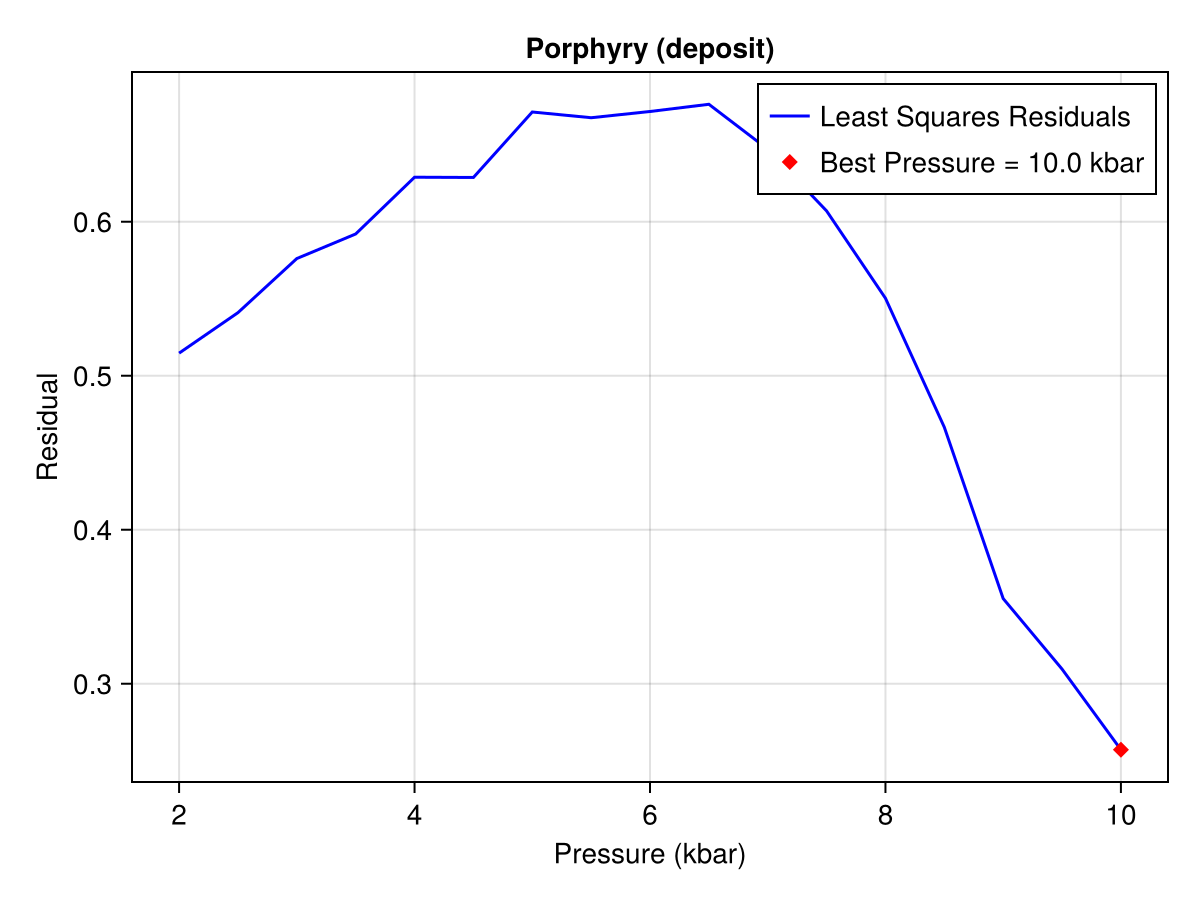

In [ ]:
# Plot residuals vs pressures
using CairoMakie

fig = Figure()
ax = Axis(fig[1, 1], xlabel="Pressure (kbar)", ylabel="Residual", title="Porphyry (deposit)")
lines!(ax, pressures, residuals, color=:blue, label="Least Squares Residuals")
scatter!(ax, [best_pressure], [min_residual], color=:red, marker=:diamond, label="Best Pressure = $best_pressure kbar")
axislegend(ax, position=:rt)

fig

In [15]:
pressures = [4.0, 7.0, 9.0, 15.0]

h2os = [2.0, 4.0, 6.0, 8.0]

fO2s = [0.0, 1.0]

T = collect(1300.0:-5.0:600.0)

buffer = "qfm"

"qfm"

In [ ]:
# Run forward models for each combination of pressure, H2O content, and fO2 offset, both for the Basalt_SB_872 and SLLB0412 bulk compositions
sat_C0s = sat_C0s_dict["SLLB0412"]
for pr in pressures
    for h2o in h2os
        for dfO2 in fO2s
            boff = zeros(length(T)) .+ dfO2
            P = fill(pr, length(T))
            println("Running buffered ECX for SLLB0412 P = $pr kbar, H2O = $h2o wt%, fO2 offset = $dfO2 log units")
            filepath = "Data/Outputs/Large22_RBLB/ECX_SLLB0412_$(Int(pr))kbar_$(Int(h2o))H2O_$(Int(dfO2))dQFM.jld2"
            if isfile(filepath)
                println("File $filepath already exists. Skipping computation.")
            else
                SLLB0412_hydr = deepcopy(SLLB0412)
                SLLB0412_hydr[11] = h2o
                SLLB0412_hydr[1:10] = SLLB0412_hydr[1:10] ./ (1.0 - h2o / 100.0) # Renormalize to anhydrous basis
                SLLB0412_hydr[9] = 2.0 
                sat_C0s = sat_C0s_dict["SLLB0412"]
                TE_0 = TE_0s_dict["SLLB0412"]
                Out_XY, Out_Sat, Out_TE, Out_Ds, Out_EuR, param_dicts = ECX_run_buffered(SLLB0412_hydr, TE_0, P, T, boff)
                @save filepath Out_XY Out_Sat Out_TE Out_Ds Out_EuR param_dicts
            end

            println("Running buffered ECX for Basalt_SB_872 P = $pr kbar, H2O = $h2o wt%, fO2 offset = $dfO2 log units")
            filepath = "Data/Outputs/Large22_RBLB/ECX_Basalt_SB_872_$(Int(pr))kbar_$(Int(h2o))H2O_$(Int(dfO2))dQFM.jld2"
            if isfile(filepath)
                println("File $filepath already exists. Skipping computation.")
            else
                Basalt_SB_872_hydr = deepcopy(Basalt_SB_872)
                Basalt_SB_872_hydr[11] = h2o
                Basalt_SB_872_hydr[1:10] = Basalt_SB_872_hydr[1:10] ./ (1.0 - h2o / 100.0) # Renormalize to anhydrous basis
                Basalt_SB_872_hydr[9] = 2.0
                sat_C0s = sat_C0s_dict["Basalt_SB_872"]
                TE_0 = TE_0s_dict["Basalt_SB_872"]
                Out_XY, Out_Sat, Out_TE, Out_Ds, Out_EuR, param_dicts = ECX_run_buffered(Basalt_SB_872_hydr, TE_0, P, T, boff)
                @save filepath Out_XY Out_Sat Out_TE Out_Ds Out_EuR param_dicts
            end

            println("Running buffered FCX for SLLB0412 P = $pr kbar, H2O = $h2o wt%, fO2 offset = $dfO2 log units")
            filepath = "Data/Outputs/Large22_RBLB/FCX_SLLB0412_$(Int(pr))kbar_$(Int(h2o))H2O_$(Int(dfO2))dQFM.jld2"
            if isfile(filepath)
                println("File $filepath already exists. Skipping computation.")
            else
                SLLB0412_hydr = deepcopy(SLLB0412)
                SLLB0412_hydr[11] = h2o
                SLLB0412_hydr[1:10] = SLLB0412_hydr[1:10] ./ (1.0 - h2o / 100.0) # Renormalize to anhydrous basis
                SLLB0412_hydr[9] = 2.0 
                sat_C0s = sat_C0s_dict["SLLB0412"]
                TE_0 = TE_0s_dict["SLLB0412"]
                Out_XY, Out_Sat, Out_TE, Out_Ds, Out_EuR, param_dicts = FCX_run_buffered(SLLB0412_hydr, TE_0, P, T, boff)
                @save filepath Out_XY Out_Sat Out_TE Out_Ds Out_EuR param_dicts
            end

            println("Running buffered FCX for Basalt_SB_872 P = $pr kbar, H2O = $h2o wt%, fO2 offset = $dfO2 log units")
            filepath = "Data/Outputs/Large22_RBLB/FCX_Basalt_SB_872_$(Int(pr))kbar_$(Int(h2o))H2O_$(Int(dfO2))dQFM.jld2"
            if isfile(filepath)
                println("File $filepath already exists. Skipping computation.")
            else
                Basalt_SB_872_hydr = deepcopy(Basalt_SB_872)
                Basalt_SB_872_hydr[11] = h2o
                Basalt_SB_872_hydr[1:10] = Basalt_SB_872_hydr[1:10] ./ (1.0 - h2o / 100.0) # Renormalize to anhydrous basis
                Basalt_SB_872_hydr[9] = 2.0
                sat_C0s = sat_C0s_dict["Basalt_SB_872"]
                TE_0 = TE_0s_dict["Basalt_SB_872"]
                Out_XY, Out_Sat, Out_TE, Out_Ds, Out_EuR, param_dicts = FCX_run_buffered(Basalt_SB_872_hydr, TE_0, P, T, boff)
                @save filepath Out_XY Out_Sat Out_TE Out_Ds Out_EuR param_dicts
            end
        end
    end
end

In [ ]:
# Iterate over all file names in "Data/Outputs/Large22_RBLB" while ignoring the "/DataFrames" subfolder

filenames = filter(f -> !occursin("DataFrames", f), readdir("Data/Outputs/Large22_RBLB/"))

elements = [:La, :Ce, :Pr, :Nd, :Sm, :Eu, :Gd, :Tb, :Dy, :Ho, :Er, :Tm, :Yb, :Lu, :Sr, :Y]

# Convert elements to strings for DataFrame column names
element_strs = string.(elements)

for file in filenames
    # Load Out_XY and Out_TE from this file
    filepath = joinpath("Data/Outputs/Large22_RBLB/", file)
    @load filepath Out_XY Out_TE
    # Create a DataFrame that has columns: Step, Temperature [°C], Oxides for all oxides in out.oxides, Elements for all elements in elements
    # Step => Index of out in Out_XY
    # Temperature [°C] => out.T_C
    # Oxides => out.bulk_M_wt for each oxide in out.oxides
    # Elements => Out_TE[Int(step)][String("liq")][Symbol(:element)] for each element in elements

    # Define cutoff indeces
    # Case 1) "ECX" in file name => cutoff index = index where out.frac_M_wt < 1e-3
    # Case 2) "FCX" in file name => cutoff index = index where out.frac_M_wt < 0.5
    cutoff_index = nothing
    if occursin("ECX", file)
        for (i, out) in enumerate(Out_XY)
            if out.frac_M_wt < 0.01
                cutoff_index = i
                break
            end
        end
    elseif occursin("FCX", file)
        for (i, out) in enumerate(Out_XY)
            if out.frac_M_wt < 0.5
                cutoff_index = i
                break
            end
        end
    end

    if cutoff_index !== nothing
        Out_XY = Out_XY[1:cutoff_index-1]
        Out_TE = Out_TE[1:cutoff_index-1]
    end

    println(Out_TE[end])

    steps = collect(1:length(Out_XY))
    temperatures = [out.T_C for out in Out_XY]

    # Initialize DataFrame with Step and Temperature columns
    df = DataFrame(Step=steps, Temperature_C=temperatures)

    # Add oxide columns
    for (i, oxide) in enumerate(Out_XY[1].oxides)
        df[!, oxide] = [out.bulk_M_wt[i] for out in Out_XY]
    end

    # Add element columns
    for (i, element) in enumerate(elements)
        df[!, string(element)] = [Out_TE[step]["liq"][element] for step in steps]
    end

    # Save to a CSV file of the same filename in "Data/Outputs/SJ17/DataFrames" folder, with the same name as the original file but with .csv extension
    csv_filename = replace(file, ".jld2" => ".csv")
    CSV.write(joinpath("Data/Outputs/Large22_RBLB/DataFrames", csv_filename), df)
end